In [ ]:
!pip install xgboost scikit-learn

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
file_path = '/content/drive/MyDrive/FYP/Datasets/machine_learning_balance_UNSW_NB15_data.csv'
df = pd.read_csv(file_path)
print(df)

             dur  spkts  dpkts         sload         dload  smeansz  dmeansz  \
0       0.000009      2      0  5.066666e+07  0.000000e+00       57        0   
1       0.000008      2      0  5.700000e+07  0.000000e+00       57        0   
2       0.025125      8     10  2.887960e+05  2.362587e+05      130       82   
3       0.051998     48     50  4.481711e+05  4.601100e+06       62      610   
4       0.000009      2      0  5.066666e+07  0.000000e+00       57        0   
...          ...    ...    ...           ...           ...      ...      ...   
642561  0.004613      4      4  7.387817e+05  4.058097e+05      142       78   
642562  0.015910     46     48  1.403897e+06  1.543734e+07       62      653   
642563  0.000008      2      0  5.700000e+07  0.000000e+00       57        0   
642564  0.000008      2      0  1.320000e+08  0.000000e+00      132        0   
642565  1.401753    102    100  8.259944e+04  9.681021e+04      143      171   

          sintpkt    dintpkt    synack 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = df.drop('label', axis=1)  # Features
y = df['label']               # Target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:25:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Detailed metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9925

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     64421
           1       0.99      1.00      0.99     64093

    accuracy                           0.99    128514
   macro avg       0.99      0.99      0.99    128514
weighted avg       0.99      0.99      0.99    128514


Confusion Matrix:
 [[63525   896]
 [   65 64028]]


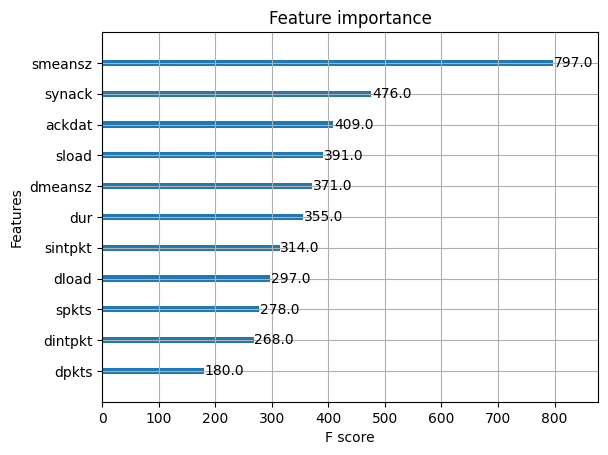

In [ ]:
import matplotlib.pyplot as plt
xgb.plot_importance(model)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb
import numpy as np

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

# Replace inf and fill missing values
X = X.replace([float('inf'), -float('inf')], pd.NA)
X = X.fillna(0)


In [ ]:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')


In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)


In [ ]:
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

Cross-Validation Accuracy Scores: [0.99249887 0.99193078 0.99286454 0.99240544 0.99311354]
Mean Accuracy: 0.9926
Standard Deviation: 0.0004
